In [1]:
import scipy.signal as sig
import numpy as np 
import matplotlib.pyplot as plt
import sounddevice as sd
import soundfile as sf

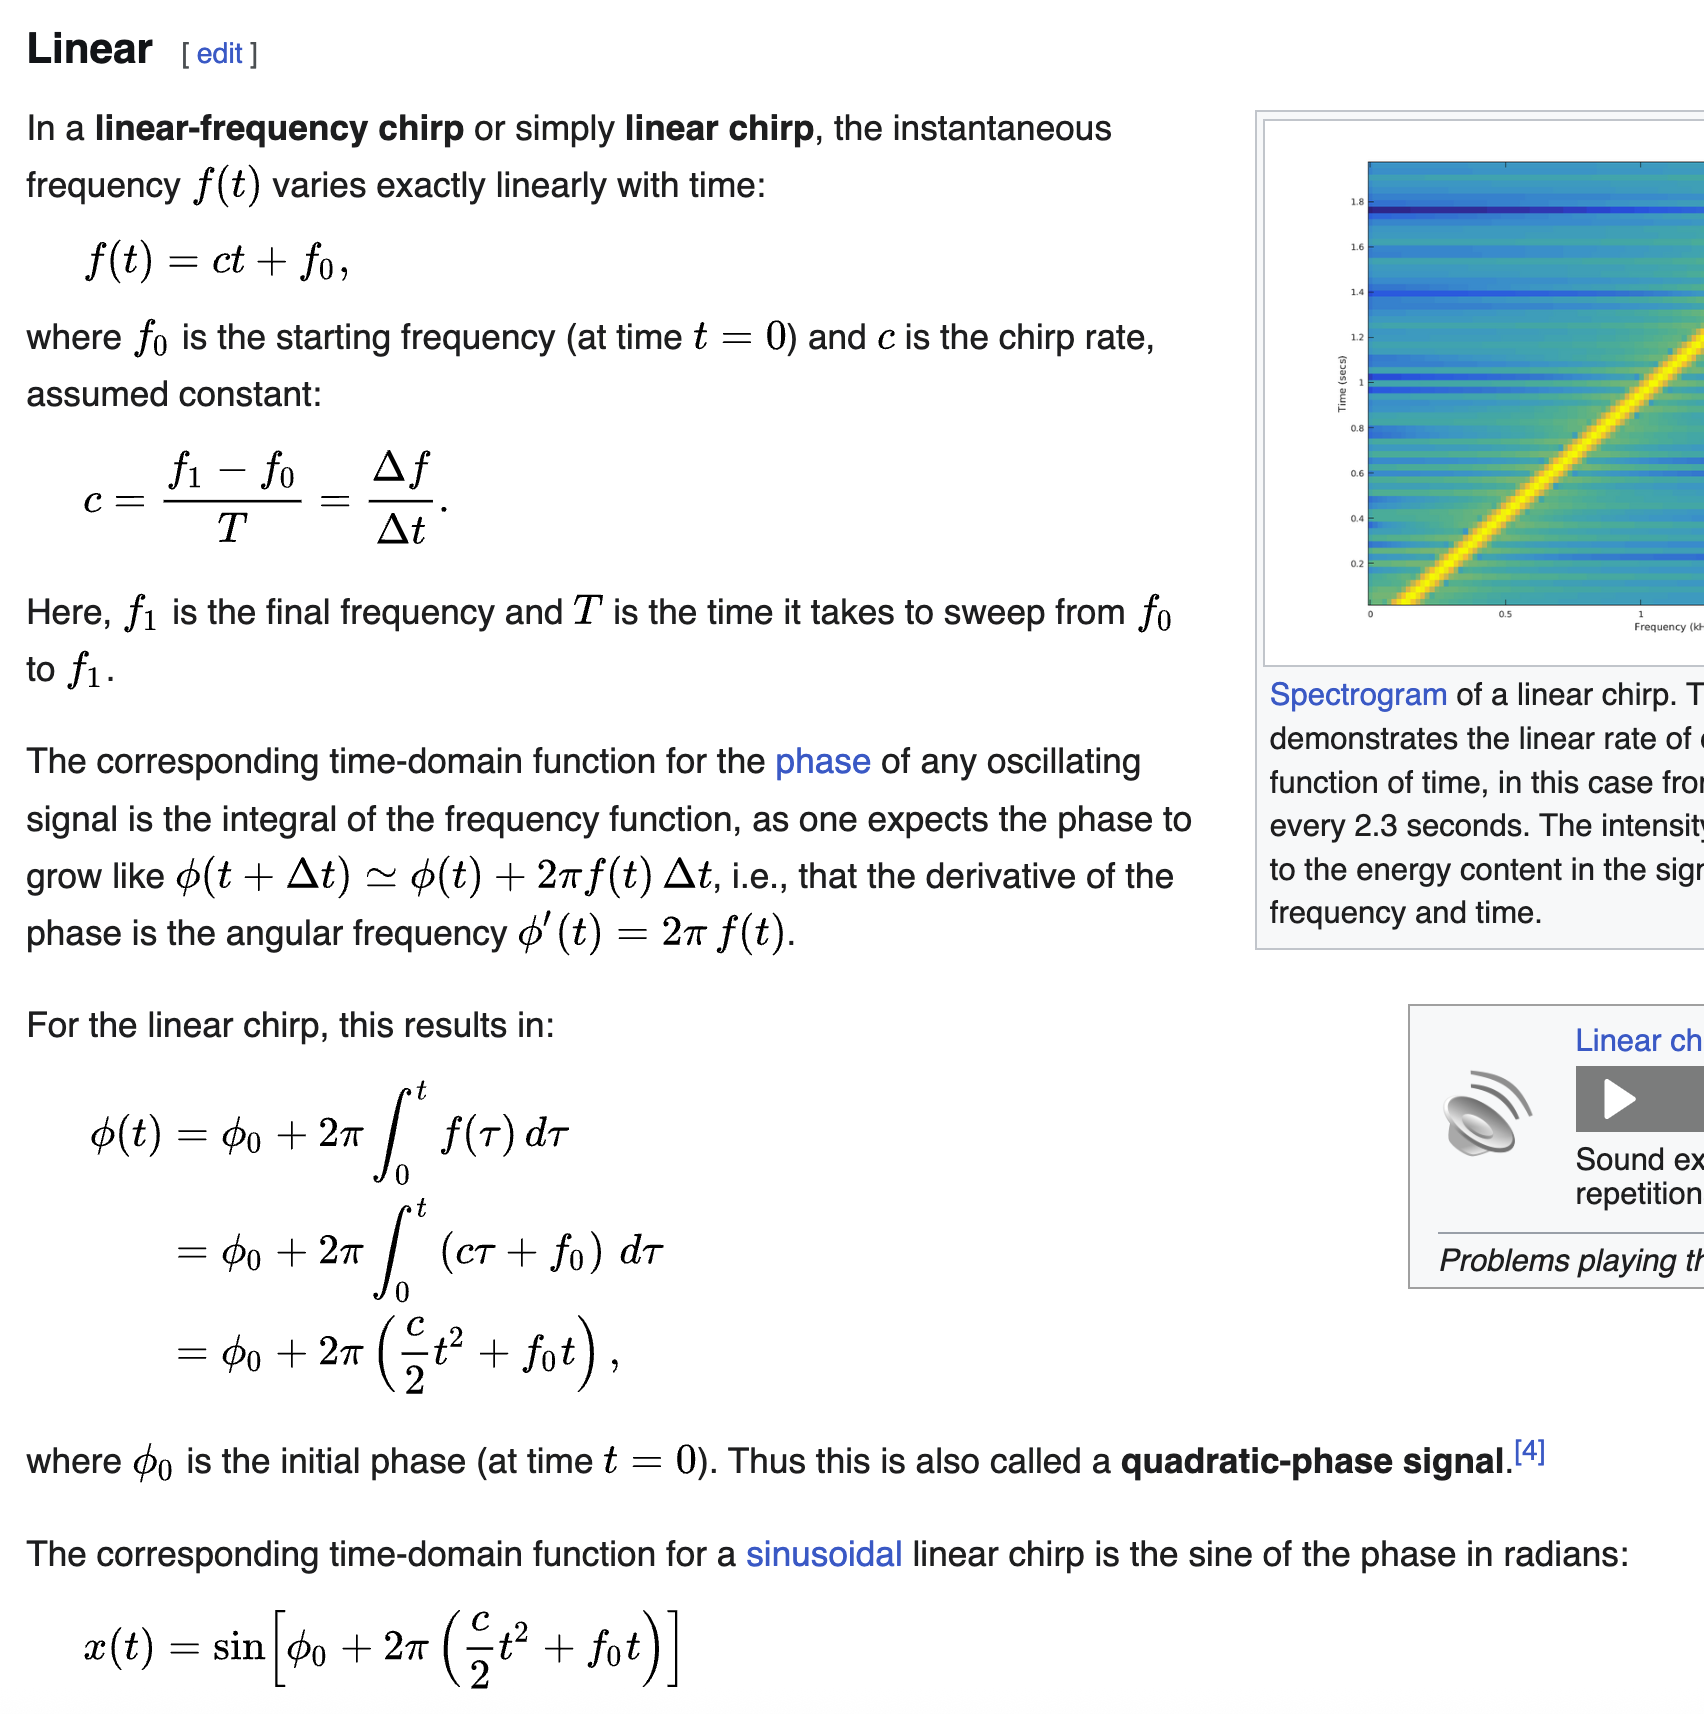


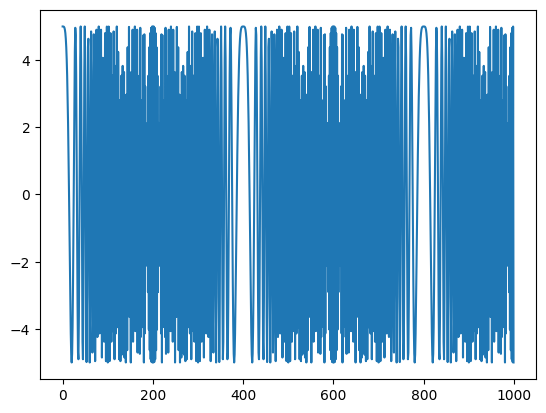

In [7]:
t = np.linspace(0, 10, 1000)
# Create a test sinusoid 
fs = int(48e3)
A = 5
phi = 0
n = np.arange(0, 1000)
f0 = 60*n 
x = A*np.cos(2*np.pi*(f0/fs)*n+phi)

plt.plot(x)

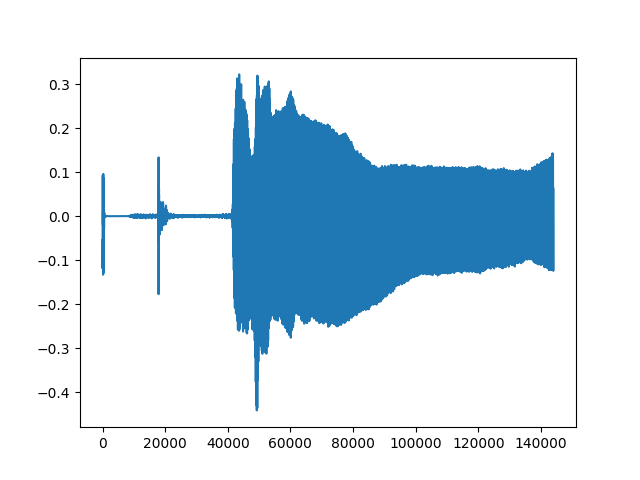

In [4]:
myrecording, fs = sf.read('hello.wav', dtype='float32')
plt.plot(myrecording)

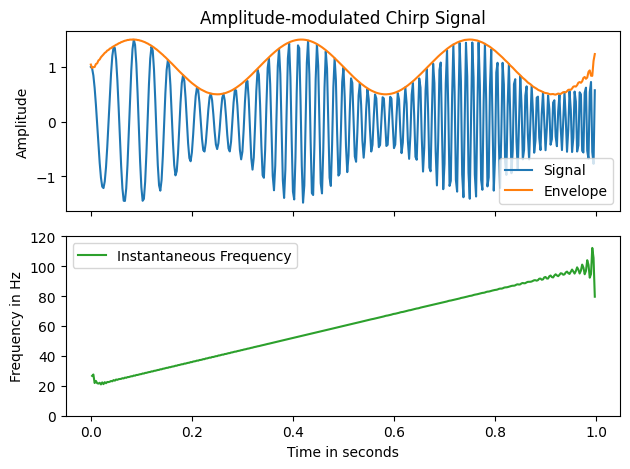

In [2]:
# example code from docs 
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import hilbert, chirp
duration, fs = 1, 400  # 1 s signal with sampling frequency of 400 Hz
t = np.arange(int(fs*duration)) / fs  # timestamps of samples
signal = chirp(t, 20.0, t[-1], 100.0)
signal *= (1.0 + 0.5 * np.sin(2.0*np.pi*3.0*t) )
analytic_signal = hilbert(signal)
amplitude_envelope = np.abs(analytic_signal)
instantaneous_phase = np.unwrap(np.angle(analytic_signal))
instantaneous_frequency = np.diff(instantaneous_phase) / (2.0*np.pi) * fs
fig, (ax0, ax1) = plt.subplots(nrows=2, sharex='all', tight_layout=True)
ax0.set_title("Amplitude-modulated Chirp Signal")
ax0.set_ylabel("Amplitude")
ax0.plot(t, signal, label='Signal')
ax0.plot(t, amplitude_envelope, label='Envelope')
ax0.legend()
ax1.set(xlabel="Time in seconds", ylabel="Frequency in Hz", ylim=(0, 120))
ax1.plot(t[1:], instantaneous_frequency, 'C2-',
         label='Instantaneous Frequency')
ax1.legend()
plt.show()

interactive(children=(IntSlider(value=0, description='X min', max=143999, step=100), IntSlider(value=144000, d…

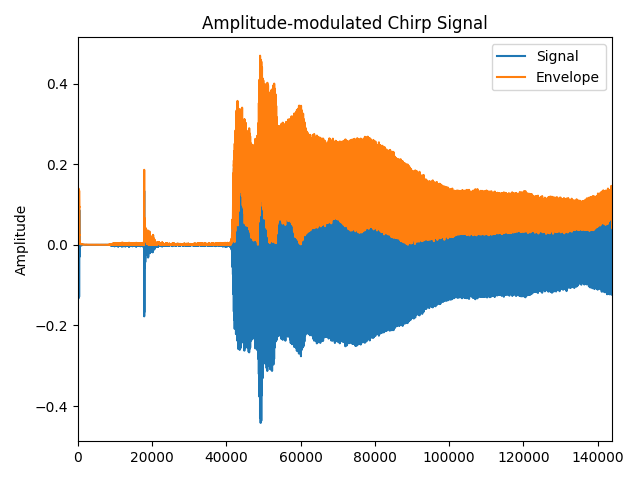

In [27]:
%matplotlib widget
from ipywidgets import interact, IntSlider

analytic_signal = hilbert(myrecording)
amplitude_envelope = np.abs(analytic_signal)
t = np.arange(len(myrecording))

fig, ax0 = plt.subplots(tight_layout=True)
ax0.set_title("Amplitude-modulated Chirp Signal")
ax0.set_ylabel("Amplitude")
line_sig, = ax0.plot(t, myrecording, label='Signal')
line_env, = ax0.plot(t, amplitude_envelope, label='Envelope')
ax0.legend()

def update(x_min, x_max):
    if x_min < x_max:
        ax0.set_xlim(x_min, x_max)
        fig.canvas.draw_idle()

interact(update,
    x_min=IntSlider(min=0, max=len(t)-1, step=100, value=0,      description='X min'),
    x_max=IntSlider(min=1, max=len(t),   step=100, value=len(t), description='X max'))
plt.show()

interactive(children=(IntSlider(value=0, description='X min', max=143999, step=100), IntSlider(value=144000, d…

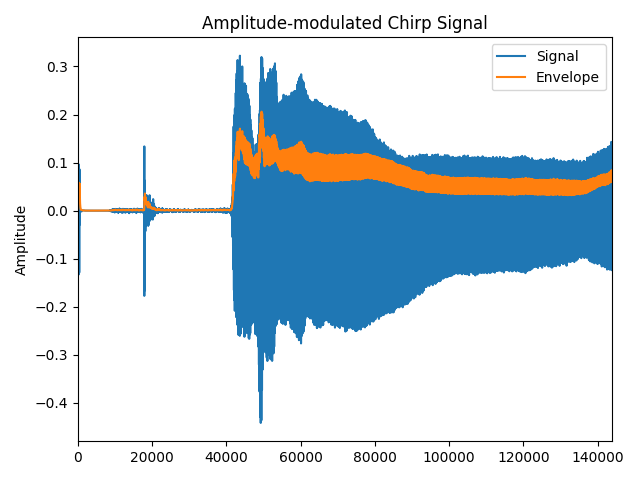

In [7]:
%matplotlib widget
from ipywidgets import interact, IntSlider
from scipy.signal import butter, sosfilt

amplitude_envelope = np.abs(myrecording)
lpfb, lpfa = np.array(sig.iirfilter(N = 1, Wn=100, btype='lowpass', output='ba', fs=fs)) 
amplitude_envelope = sig.lfilter(lpfb, lpfa, amplitude_envelope)
t = np.arange(len(myrecording))

fig, ax0 = plt.subplots(tight_layout=True)
ax0.set_title("Amplitude-modulated Chirp Signal")
ax0.set_ylabel("Amplitude")
line_sig, = ax0.plot(t, myrecording, label='Signal')
line_env, = ax0.plot(t, amplitude_envelope, label='Envelope')
ax0.legend()

def update(x_min, x_max):
    if x_min < x_max:
        ax0.set_xlim(x_min, x_max)
        fig.canvas.draw_idle()

interact(update,
    x_min=IntSlider(min=0, max=len(t)-1, step=100, value=0,      description='X min'),
    x_max=IntSlider(min=1, max=len(t),   step=100, value=len(t), description='X max'))
plt.show()

Ways to extract envelope: 
* Rectify and smooth (fold up negative half cycle so signal is always positive), then low pass filter -> cutoff of the LPF controls the trade off (high vs low cutoff has smooth envelope )


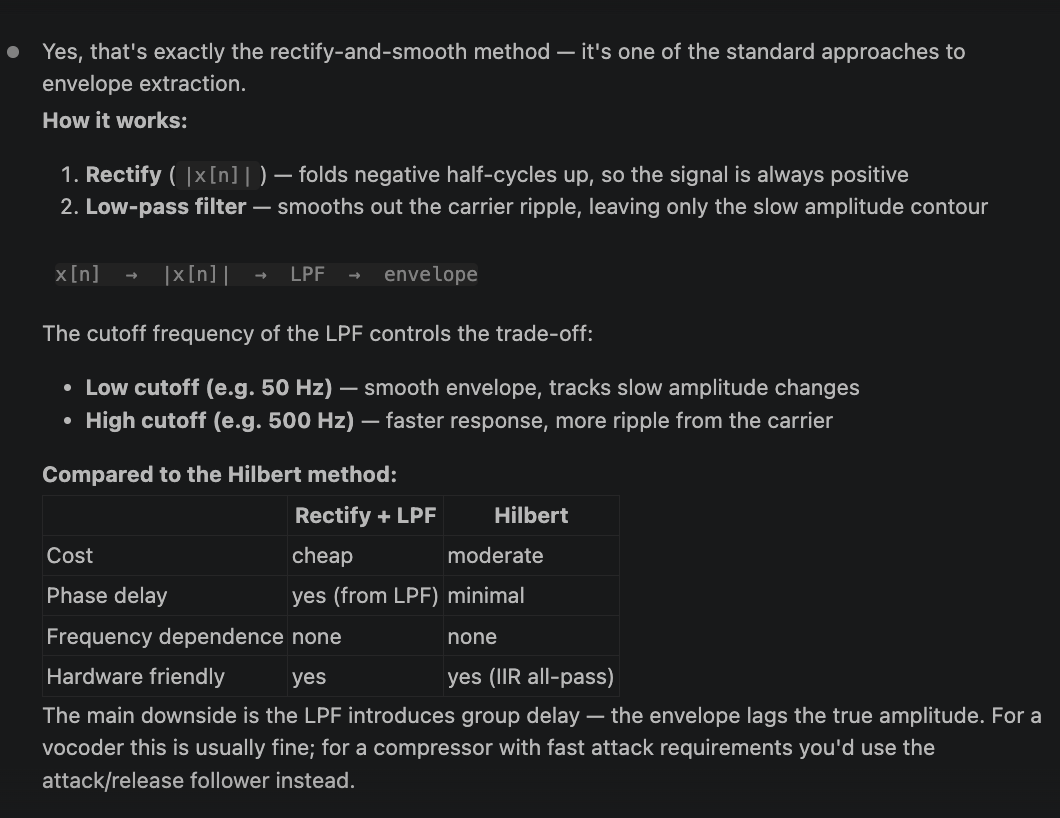